{'poem': '《莲花》\n素蘤多蒙别艳欺，此花端合在瑶池。\n无情有恨何人觉，月晓风清欲堕时。\n\n赏析：这首作品以莲花为吟咏对象，通过“素蘤”与“别艳”的对比，突显莲花清雅高洁之姿。后两句以“月晓风清”为背景，勾勒莲花将凋未凋之态，暗含孤芳自赏的幽怨。全诗意象空灵，托物言志，既赞莲花超凡脱俗之质，又寄寓了文人孤高自守的情怀。', 'ci_poem': '《莲华辞》\n（仿楚辞体）\n\n灵波澹兮被清露，芙蓉发兮濯沧浪。\n云衣裳兮佩琼玖，顾影娉婷兮水中央。\n\n朝饮泽畔之沆瀣，夕餐菊落之玄霜。\n揽星斗以为佩，结春冰作霓裳。\n风飒飒兮吹碧叶，雨冥冥兮湿幽芳。\n\n望洞庭兮波渺渺，思帝子兮隔潇湘。\n采莲人兮归未归，兰舟远兮烟水长。\n折芳馨兮欲谁赠，月徘徊兮照空江。\n\n忽闻瑶瑟鸣幽浦，疑是湘灵舞霓旌。\n千载淤泥凝玉魄，九秋霜雪铸冰情。\n终不染兮终不折，立苍茫兮独亭亭。\n\n乱曰：浊世昏昏兮，众芳芜秽；\n独抱素心兮，与月同辉。\n香远益清兮，君子之德；\n风裳水佩兮，亘古崔巍。', 'joke': '这个笑话需要一定文学素养才能看懂，但看懂后绝对会心一笑。\n\n---\n\n**《爱莲说》新解**\n\n有个文人，特别喜欢周敦颐的《爱莲说》，尤其那句“出淤泥而不染”，觉得意境高远，是他的座右铭。\n\n他给自己取了个网名叫【淤泥】，个性签名写着：“我是那滩成就莲花的淤泥。”\n\n他追一个网名叫【莲花】的姑娘，每天在人家朋友圈评论：“莲，你应该感谢我，没有我的滋养，你怎能如此高洁？”\n\n姑娘一直没理他。他急了，发私信：“我对你这么好，你为何视而不见？”\n\n姑娘终于回复了：“你知道莲花是完全自养植物吗？你天天在底下看着我，我心里清楚得很。”\n\n文人：“清楚什么？”\n\n姑娘：“你虽然顶着我的名，但其实你根本看不清我——毕竟，**‘莲，之出淤泥而不染’里的‘之’，是语气助词，不是说你——‘只’出不染。你粘着我，我这朵莲花早就被你整得‘不染’了，你还觉得你功高盖世呢？”'}


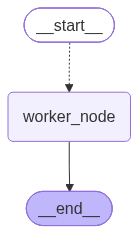

In [12]:
from typing import TypedDict, Literal, Sequence

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langgraph.types import Send

load_dotenv(override=True)

CONTENT_TYPES = ["poem", "joke", "ci_poem"]

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {"type": "disabled"}
    }
)

# ====================== 状态定义 ======================
class InputState(TypedDict):
    topic: str

class OutputState(TypedDict):
    poem: str
    ci_poem: str
    joke: str

class WorkerState(TypedDict):
    content_type: Literal["poem", "joke", "ci_poem"]
    prompt: str
    topic: str  # 必须带上，用于合并

# ====================== 节点 ======================
def worker_node(state: WorkerState):
    prompt = state["prompt"]
    res = model.invoke([HumanMessage(content=prompt)])
    return {
        state["content_type"]: res.content
    }


# ====================== 路由 ======================
def router(state: InputState) -> Sequence[Send]:
    en2cn = {
        "poem": "唐诗",
        "joke": "笑话",
        "ci_poem": "楚辞"
    }
    topic = state["topic"]
    sends = []
    for t in CONTENT_TYPES:
        sends.append(Send(
            "worker_node",
            {
                "content_type": t,
                "prompt": f"以{topic}为主题，创作一首{en2cn[t]}",
            }
        ))
    return sends

# ====================== 构建图 ======================
builder = StateGraph(
    input_schema=InputState,
    state_schema=OutputState,
    output_schema=OutputState
)

builder.add_node("worker_node", worker_node)

# 动态派发
builder.add_conditional_edges(START, router,
                              path_map=["worker_node"
                                        ])
# 所有 worker 执行完进入收集，再结束
builder.add_edge("worker_node", END)

graph = builder.compile()
res=graph.invoke({"topic": "莲花"})
print(res)
display(graph)






